## import

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
sys.path.append(f'{os.getcwd()}/irc_gym')
from ult import *
from irc_gym.irc.model import FuncBeliefModel
from stable_baselines3 import PPO
from auditoryforage.AF_env import AuditoryForagingReward2 as AFR2


## train

In [3]:
# train all agent at the same time (not family)
modelname = 'varynodenoperoidv2'

epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 333
vmin, vmax = 10, 1000
food_reward_list = np.linspace(vmin, vmax, 9)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]


for iepoch in range(n_epoch):

    for node in node_list:

        thismodel = f'seed{seed}_{modelname}_n{node}_ep{iepoch}'
        
        task = AFR2(spec={'agent':
                          {'lick_cost': env_param[0],
                           'food_reward': env_param[1],
                           'attention_cost_coeff': env_param[2],
                           'attention_cost_temp': env_param[3],
                           'penalty_cost': env_param[4],
                           'iti_cost': env_param[5],
                           'time_in_game_reward': env_param[6]},
                          'experiment': {'no_signal_nodes': node}})
        task.food_reward_list = food_reward_list
        taskbelief = FuncBeliefModel(env=task, rng=1)
        task.obs_certainity_possible = p1p2

        # train
        if iepoch == 0:
            model = PPO('MlpPolicy', taskbelief, verbose=0, device='cpu',
                        clip_range=0.1, ent_coef=0.01)
        else:
            previous_model = f'seed{seed}_{modelname}_n{node}_ep{iepoch-1}'
            model = PPO.load(previous_model, env=taskbelief)
        model.learn(total_timesteps=epoch_size,)
        model.save(thismodel)
        print(f'epoch{iepoch}, node{node}: {thismodel} saved')

    if iepoch < 5:
        continue  # skip early plots

    for food_reward_idx in range(len(food_reward_list)):
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

        # autocorr.
        for node in node_list:
            thismodel = f'seed{seed}_{modelname}_n{node}_ep{iepoch}'
            task = AFR2(spec={'agent':
                              {'lick_cost': env_param[0],
                               'food_reward': env_param[1],
                               'attention_cost_coeff': env_param[2],
                               'attention_cost_temp': env_param[3],
                               'penalty_cost': env_param[4],
                               'iti_cost': env_param[5],
                               'time_in_game_reward': env_param[6]},
                              'experiment': {'no_signal_nodes': node}})
            task.food_reward_list = food_reward_list
            taskbelief = FuncBeliefModel(env=task, rng=1)
            task.obs_certainity_possible = p1p2
            model = PPO.load(thismodel)

            def eval_wrapper(a):
                episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                          num_steps=100000, deterministic=True)
                return episode

            with multiprocess.Pool(processes=6) as pool:
                all_episode_data = pool.map(eval_wrapper, range(no_episodes))

            all_reward_res = {}  # k: v = foodreward idx: this food reward res
            for r in range(len(food_reward_list)):
                attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = [], [], [], [], [], []
                all_reward_res[r] = attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len

            for episode in all_episode_data:
                attention_prob_list, lick_prob_list, noise_prob_list, lick_time_list, att_time_list, trial_len = all_reward_res[
                    episode['trial_food_reward_idx']]
                att_time_list.append(
                    np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
                if episode['actions'][-1][0] == 1:
                    lick_time_list.append(len(episode['states']))
                else:
                    lick_time_list.append(None)
                trial_len.append(len(episode['actions']))

            # auto correlation
            att_seq_list = []
            for episode in all_episode_data:
                if episode['trial_food_reward_idx'] == food_reward_idx:
                    att_seq_list.append([float(elt[1])
                                        for elt in episode['actions']])
            # Sorting based on increasing trial length
            sorted_list_of_lists = sorted(att_seq_list, key=len)
            # Choosing what range of trial lengths to use. Could modify to be more consistent.
            sequences = sorted_list_of_lists[-plot_no_episodes:]
            # autocorr
            autocorr, total_counts = empirical_autocorrelation(
                sequences, min_no_samples=1111)
            xs = np.arange(0, len(autocorr), 1)
            xs = xs-len(xs)//2
            ax1.plot(xs, autocorr,
                     label=f'food reward={food_reward_list[r]:.0f}')
            # trial len dist
            sns.kdeplot([len(a) for a in att_seq_list],
                        fill=False, bw_adjust=0.5, ax=ax2)

        ax1.set_xlabel(r'$\tau$ [s]')
        ax1.set_title('auto correlation')
        # ax1.set_xlim(-50,50)
        ax1.set_ylim(0, .1)
        ax1.set_xticks([-50, 0, 50])
        ax1.set_yticklabels([])
        centerax(ax1)
        quickleg(ax1)
        ax2.set_xlabel('trial length')
        ax2.set_ylabel('probablity')
        ax2.set_xlim(0, 80)
        ax2.set_title('trial length distribution')

        plt.legend(bbox_to_anchor=(1, 0))
        plt.tight_layout()
        quicksave('autocorr', modelname)
        plt.show()

/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(
/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


epoch0, node10: seed0_varynodenoperoidv2_n10_ep0 saved


/Users/yc/miniconda3/envs/lab/lib/python3.11/site-packages/stable_baselines3/common/vec_env/patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


epoch0, node25: seed0_varynodenoperoidv2_n25_ep0 saved
epoch0, node40: seed0_varynodenoperoidv2_n40_ep0 saved
epoch1, node10: seed0_varynodenoperoidv2_n10_ep1 saved


KeyboardInterrupt: 

ycstore/seed_0_varynodenoperoid_10_epoch_20


ycstore/seed_0_varynodenoperoid_25_epoch_20


/Users/yc/repo/auditory-foraging-IRC/ult.py:562: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


ycstore/seed_0_varynodenoperoid_40_epoch_20


/Users/yc/repo/auditory-foraging-IRC/ult.py:562: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)
/Users/yc/repo/auditory-foraging-IRC/ult.py:562: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


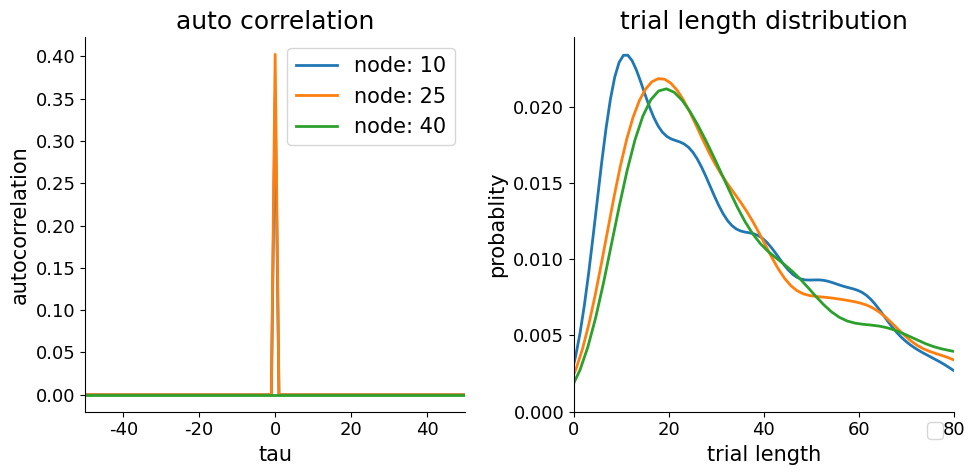

ycstore/seed_0_varynodenoperoid_10_epoch_20
ycstore/seed_0_varynodenoperoid_25_epoch_20


/Users/yc/repo/auditory-foraging-IRC/ult.py:562: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)


ycstore/seed_0_varynodenoperoid_40_epoch_20


/Users/yc/repo/auditory-foraging-IRC/ult.py:562: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)
/Users/yc/repo/auditory-foraging-IRC/ult.py:562: RuntimeWarning: invalid value encountered in divide
  autocorr /= np.max(autocorr)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


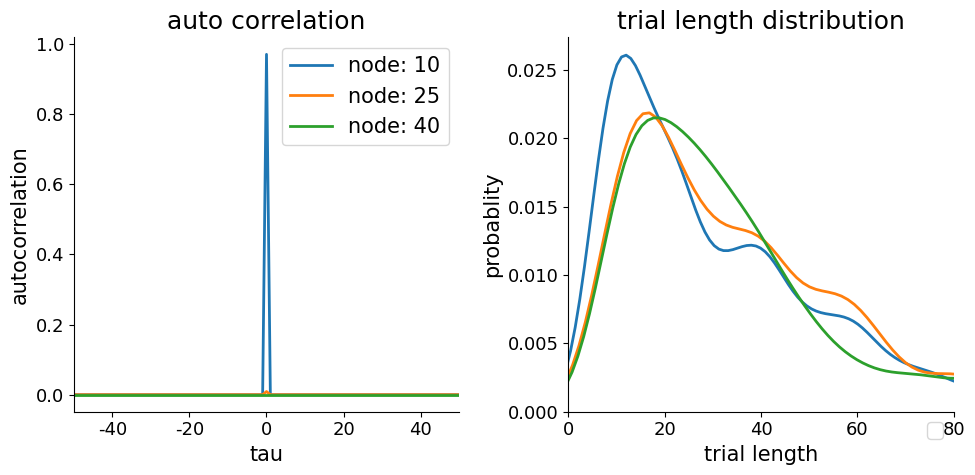

In [ ]:
epochtouse=20


modelname = 'varynodenoperoidv2'
epoch_size = 33333
n_epoch = 55
n_seed = 1
seed = 0
no_episodes = 3333  # for eval plot during training
plot_no_episodes = 333
vmin, vmax = 10, 1000
food_reward_list = np.linspace(vmin, vmax, 9)
attcost = -1.6
facost = -50
p1p2 = np.array([.6, .7])
env_param = [0, None, attcost, .25, facost, 0, 0]
np.random.seed(seed)
node_list = [10, 25, 40]


iepoch=epochtouse
for food_reward_idx in range(len(food_reward_list)):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 5))

    # autocorr.
    for node in node_list:
        thismodel = f'seed{seed}_{modelname}_n{node}_ep{iepoch}'
        task = AFR2(spec={'agent':
                            {'lick_cost': env_param[0],
                            'food_reward': env_param[1],
                            'attention_cost_coeff': env_param[2],
                            'attention_cost_temp': env_param[3],
                            'penalty_cost': env_param[4],
                            'iti_cost': env_param[5],
                            'time_in_game_reward': env_param[6]},
                            'experiment': {'no_signal_nodes': node}})
        task.food_reward_list = food_reward_list
        taskbelief = FuncBeliefModel(env=task, rng=1)
        task.obs_certainity_possible = p1p2
        model = PPO.load(thismodel)
        
        def eval_wrapper(a):
            episode = run_one_episode(task=task, taskbelief=taskbelief, agent=model,
                                    num_steps=100000, deterministic=True)
            return episode

        with multiprocess.Pool(processes=6) as pool:
            all_episode_data = pool.map(eval_wrapper, range(no_episodes))

        # all_reward_res={} # k: v = foodreward idx: this food reward res
        # for r in range(len(food_reward_list)):
        #     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=[],[],[],[],[],[]
        #     all_reward_res[r]=attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len

        # for episode in all_episode_data:
        #     attention_prob_list,lick_prob_list,noise_prob_list, lick_time_list,att_time_list,trial_len=all_reward_res[episode['trial_food_reward_idx']]
        #     att_time_list.append(
        #         np.where(np.array([elt[1] for elt in episode['actions']]) == 1)[0])
        #     if episode['actions'][-1][0] == 1:
        #         lick_time_list.append(len(episode['states']))
        #     else:
        #         lick_time_list.append(None)
        #     trial_len.append(len(episode['actions']))

        # auto correlation 
        att_seq_list = []
        for episode in all_episode_data:
            if episode['trial_food_reward_idx'] == food_reward_idx:
                att_seq_list.append([float(elt[1])
                                    for elt in episode['actions']])
        # Sorting based on increasing trial length
        sorted_list_of_lists = sorted(att_seq_list, key=len)
        # Choosing what range of trial lengths to use. Could modify to be more consistent.
        sequences = sorted_list_of_lists[-plot_no_episodes:]
        # autocorr
        autocorr, total_counts = empirical_autocorrelation(
            sequences, min_no_samples=1111)
        xs = np.arange(0, len(autocorr), 1)
        xs = xs-len(xs)//2
        ax1.plot(xs, autocorr,
                    label=f'food reward={food_reward_list[r]:.0f}')
        # trial len dist
        sns.kdeplot([len(a) for a in att_seq_list],
                    fill=False, bw_adjust=0.5, ax=ax2)

    ax1.set_xlabel(r'$\tau$ [s]')
    ax1.set_title('auto correlation')
    # ax1.set_xlim(-50,50)
    ax1.set_ylim(0, .1)
    ax1.set_xticks([-50, 0, 50])
    ax1.set_yticklabels([])
    centerax(ax1)
    quickleg(ax1)
    ax2.set_xlabel('trial length')
    ax2.set_ylabel('probablity')
    ax2.set_xlim(0, 80)
    ax2.set_title('trial length distribution')

    plt.legend(bbox_to_anchor=(1, 0))
    plt.tight_layout()
    quicksave('autocorr', modelname)
    plt.show()

        